# Weekly ETF Risk Monitor: End-to-End Project Pipeline

**Sole author:** Paritosh Dwivedi

## Objective and stakeholder question

This notebook builds a reproducible SPY risk-monitoring pipeline for a portfolio manager's weekly review.

**Decision question:** Should the portfolio manager maintain the current SPY exposure or investigate reducing it because near-term risk appears elevated?

**Success criteria:** validated immutable raw data, reproducible processed data, chronological out-of-sample evaluation, a clear current risk signal, and explicit assumptions and limitations.

In [1]:
# --- run me first: makes this notebook work wherever it lives ---
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import pandas as pd
from IPython.display import Image, display

from run_pipeline import run
from src.config import get_settings

settings = get_settings()
print('working from:', ROOT.name)
print('sole author: Paritosh Dwivedi')

working from: project
sole author: Paritosh Dwivedi


## Analysis plan

1. Acquire or reload a recorded daily SPY snapshot.
2. Validate schema, types, missingness, duplicates, ordering, and price ranges.
3. Clean without modifying the raw artifact.
4. Retain plausible tail observations and flag extreme returns.
5. Build lagged and rolling features without look-ahead.
6. Predict five-day realized volatility with Ridge regression.
7. Classify elevated-risk forecast windows using a training-derived threshold and a documented score cutoff.
8. Purge five sessions between training and holdout targets.
9. Compare with baselines, non-overlapping samples, walk-forward folds, and sensitivity checks.
10. Refit production models on all labeled history and translate the latest result into a stakeholder signal.

The smallest complete baseline is executed before any optional model expansion.

## 1. Execute the complete reproducible pipeline

The default run uses the latest validated raw snapshot. Pass `refresh=True` only when a new provider pull is intended; each refresh creates a new immutable raw file.

In [2]:
metrics = run(refresh=False)
print('pipeline completed for:', metrics['ticker'])
print('generated at:', metrics['generated_at_utc'])

pipeline completed for: SPY
generated at: 2026-08-18T00:26:25.267285+00:00


## 2. Data source and validation

In [3]:
data_summary = {
    'provider': metrics['data']['acquisition'].get('provider'),
    'raw_file': metrics['data']['raw_file'],
    'rows': metrics['data']['rows_raw'],
    'date_start': metrics['data']['date_start'],
    'date_end': metrics['data']['date_end'],
    'validation_passed': metrics['data']['raw_validation']['valid'],
    'missing_values': metrics['data']['raw_validation']['missing_values'],
    'duplicate_dates': metrics['data']['raw_validation']['duplicate_dates'],
}
pd.Series(data_summary, name='value').to_frame()

,value
provider,yfinance
raw_file,data/raw/spy_daily_20260817T224143Z.csv
rows,4180
date_start,2010-01-04
date_end,2026-08-17
validation_passed,True
missing_values,0
duplicate_dates,0


The raw file is preserved under `data/raw/` with a retrieval timestamp and SHA-256 manifest. Processed outputs are derived by code and can be regenerated.

In [4]:
processed = pd.read_parquet(ROOT / metrics['data']['model_dataset_file'])
display(processed[['date', 'adjusted_close', 'daily_return', 'rolling_vol_20', 'drawdown', 'target_next_week_vol']].tail())
print('processed rows:', len(processed))
print('flagged retained return outliers:', metrics['data']['return_outliers_flagged'])

,date,adjusted_close,daily_return,rolling_vol_20,drawdown,target_next_week_vol
4175,2026-08-11,770.559998,-0.003195,0.140565,-0.003492,NaN
4176,2026-08-12,772.489990,0.002505,0.140286,-0.000996,NaN
4177,2026-08-13,777.880005,0.006977,0.139455,0.000000,NaN
4178,2026-08-14,776.340027,-0.001980,0.133304,-0.001980,NaN
4179,2026-08-17,772.669983,-0.004727,0.134933,-0.006698,NaN


processed rows: 4180
flagged retained return outliers: 31


## 3. Market and risk context

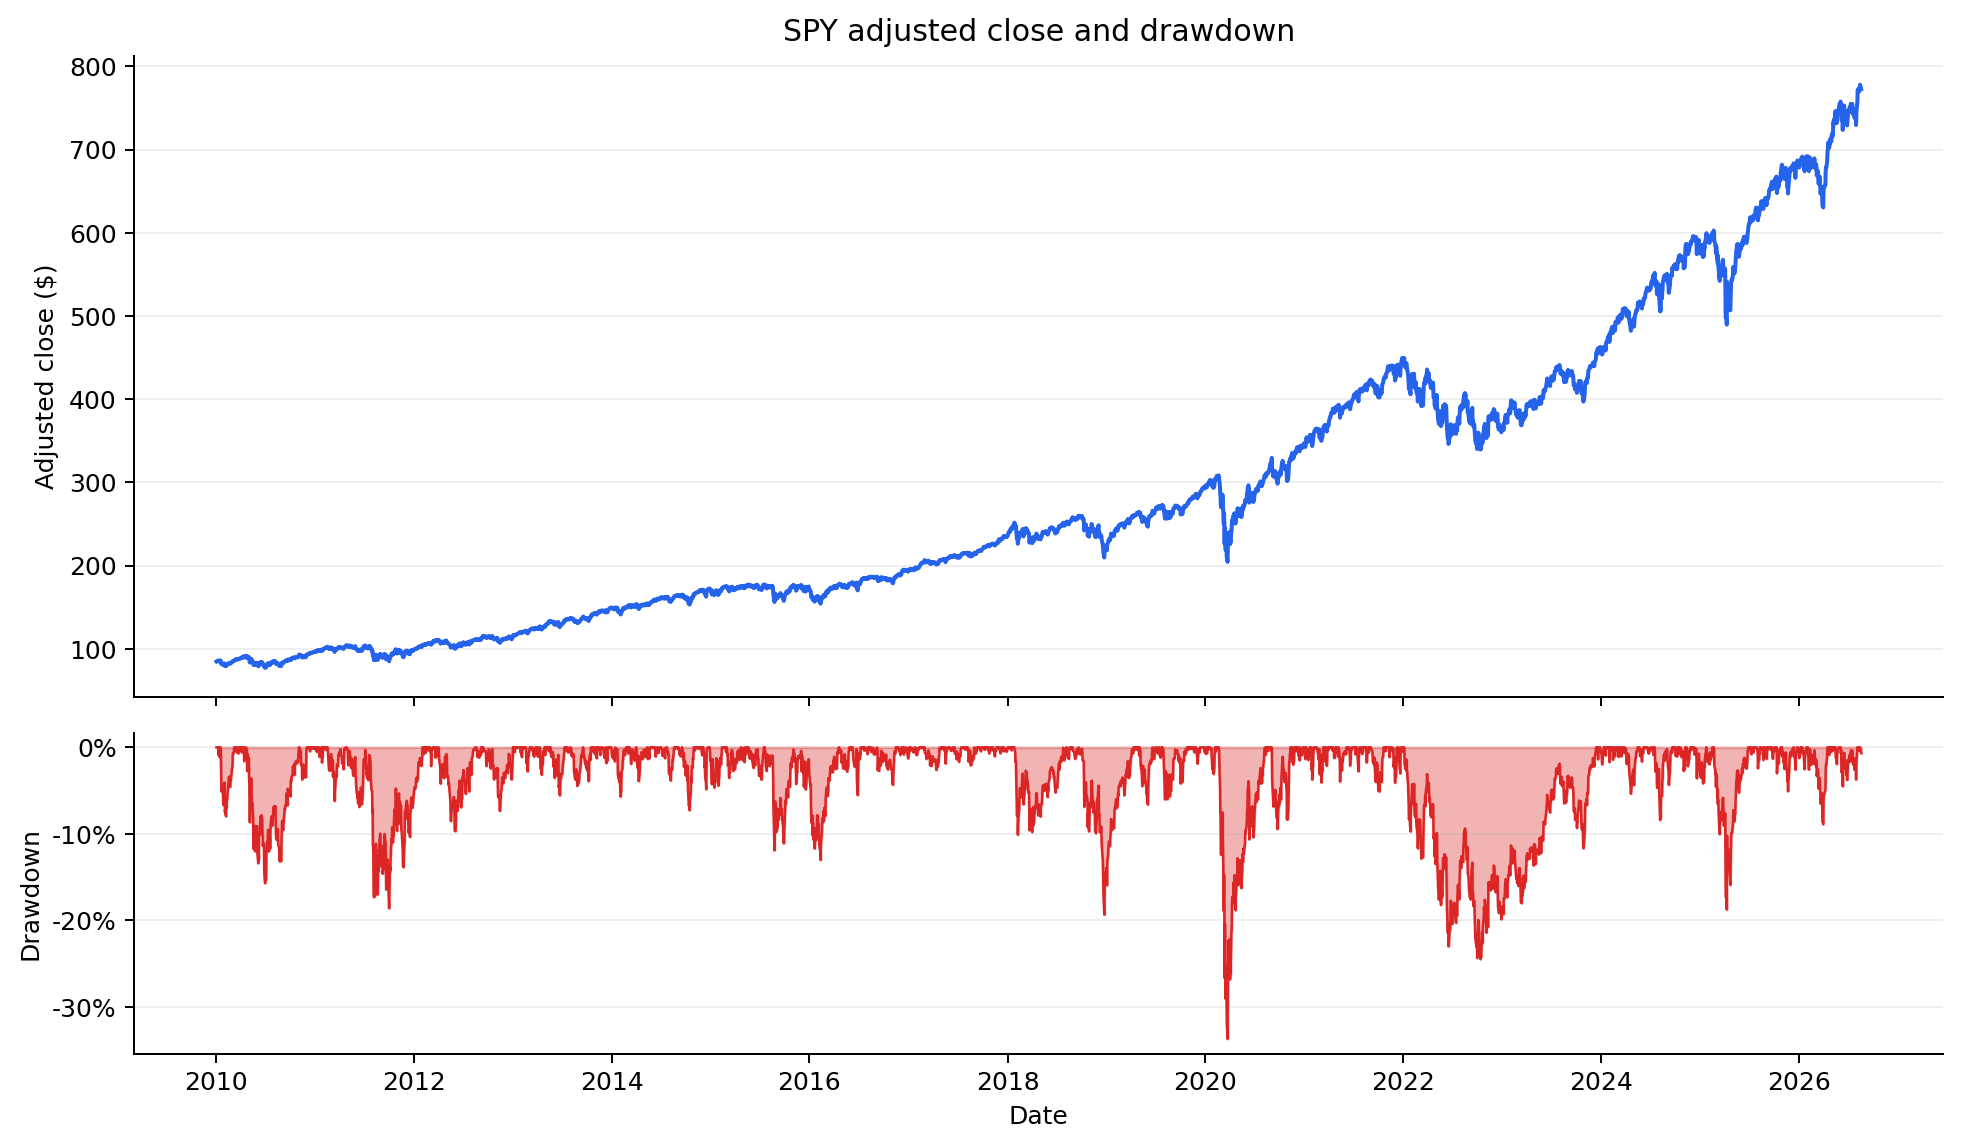

In [5]:
display(Image(filename=str(ROOT / 'reports/images/price_and_drawdown.png'), width=900))

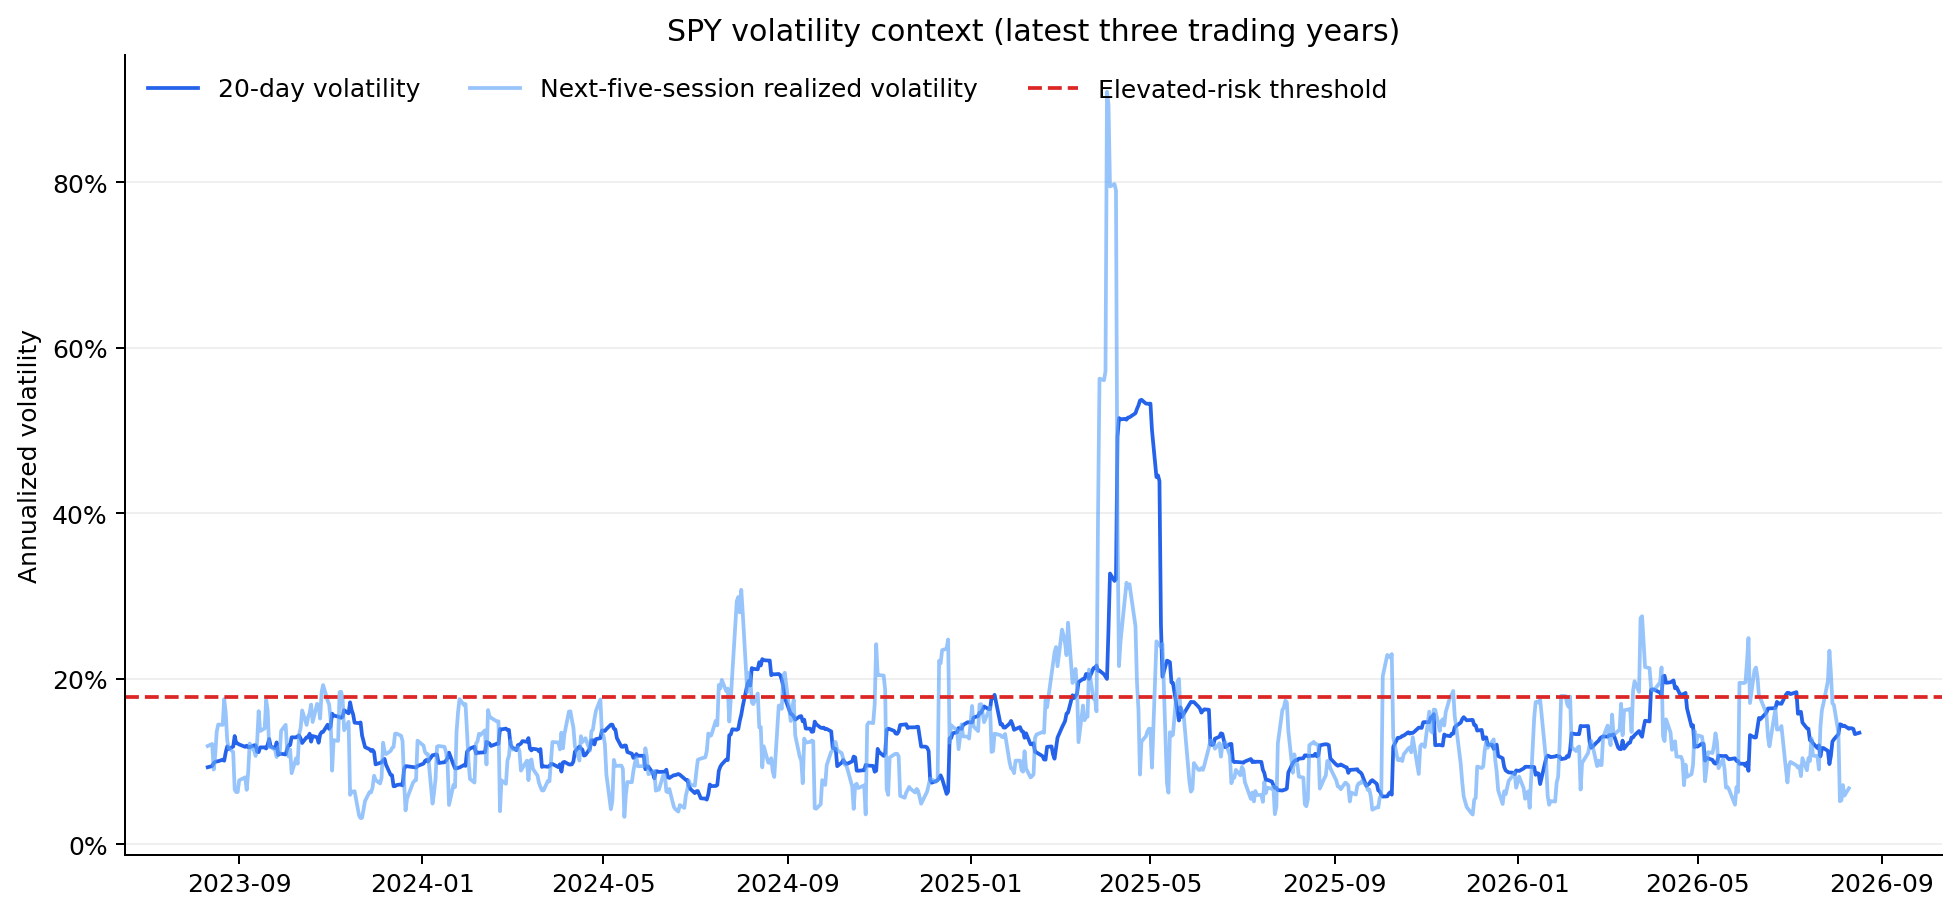

In [6]:
display(Image(filename=str(ROOT / 'reports/images/volatility_and_risk_threshold.png'), width=900))

Plausible extremes are retained because tail events are central to risk decisions. Robust outlier location and scale are fit only on the allowed training history during evaluation, then refit on all labeled history for production scoring. The flag supports diagnosis without deleting market stress.

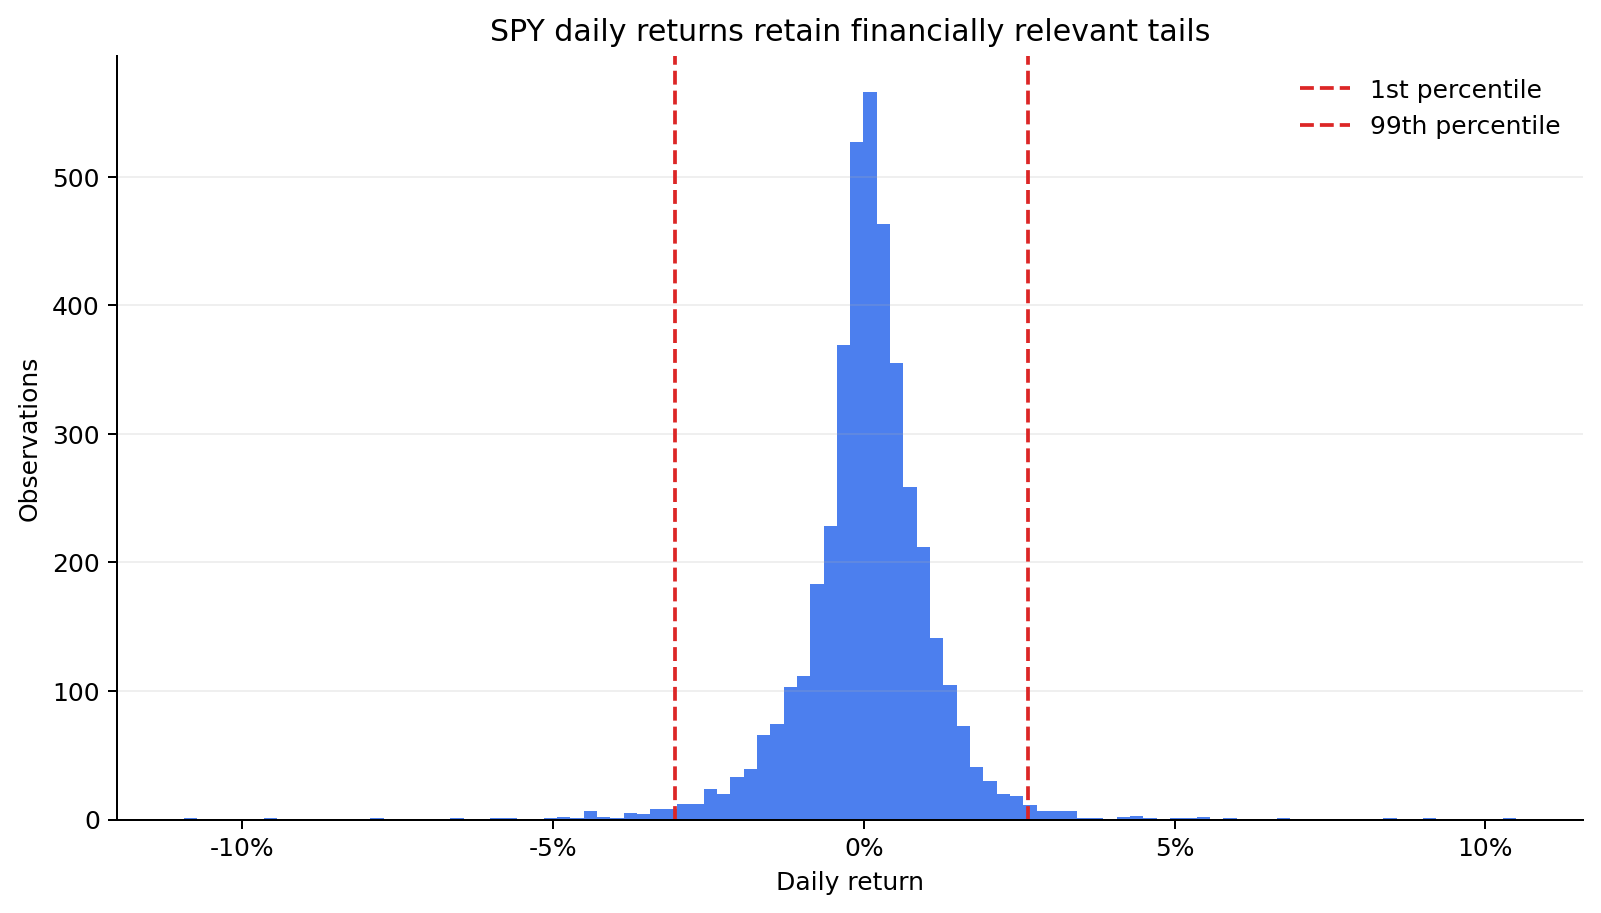

In [7]:
display(Image(filename=str(ROOT / 'reports/images/return_distribution.png'), width=800))

## 4. Chronological model evaluation

In [8]:
regression = metrics['models']['regression']
regression_table = pd.DataFrame({
    'Ridge': regression['ridge'],
    'Recent-vol baseline': regression['recent_volatility_baseline'],
    'Historical-mean baseline': regression['historical_mean_baseline'],
}).T
display(regression_table.round(4))
print(f"Ridge MAE improvement vs recent-vol baseline: {regression['ridge_mae_improvement_vs_recent']:.1%}")

,mae,rmse,r2
Ridge,0.0402,0.0658,0.3357
Recent-vol baseline,0.0507,0.0864,-0.1447
Historical-mean baseline,0.0517,0.0821,-0.0338


Ridge MAE improvement vs recent-vol baseline: 20.8%


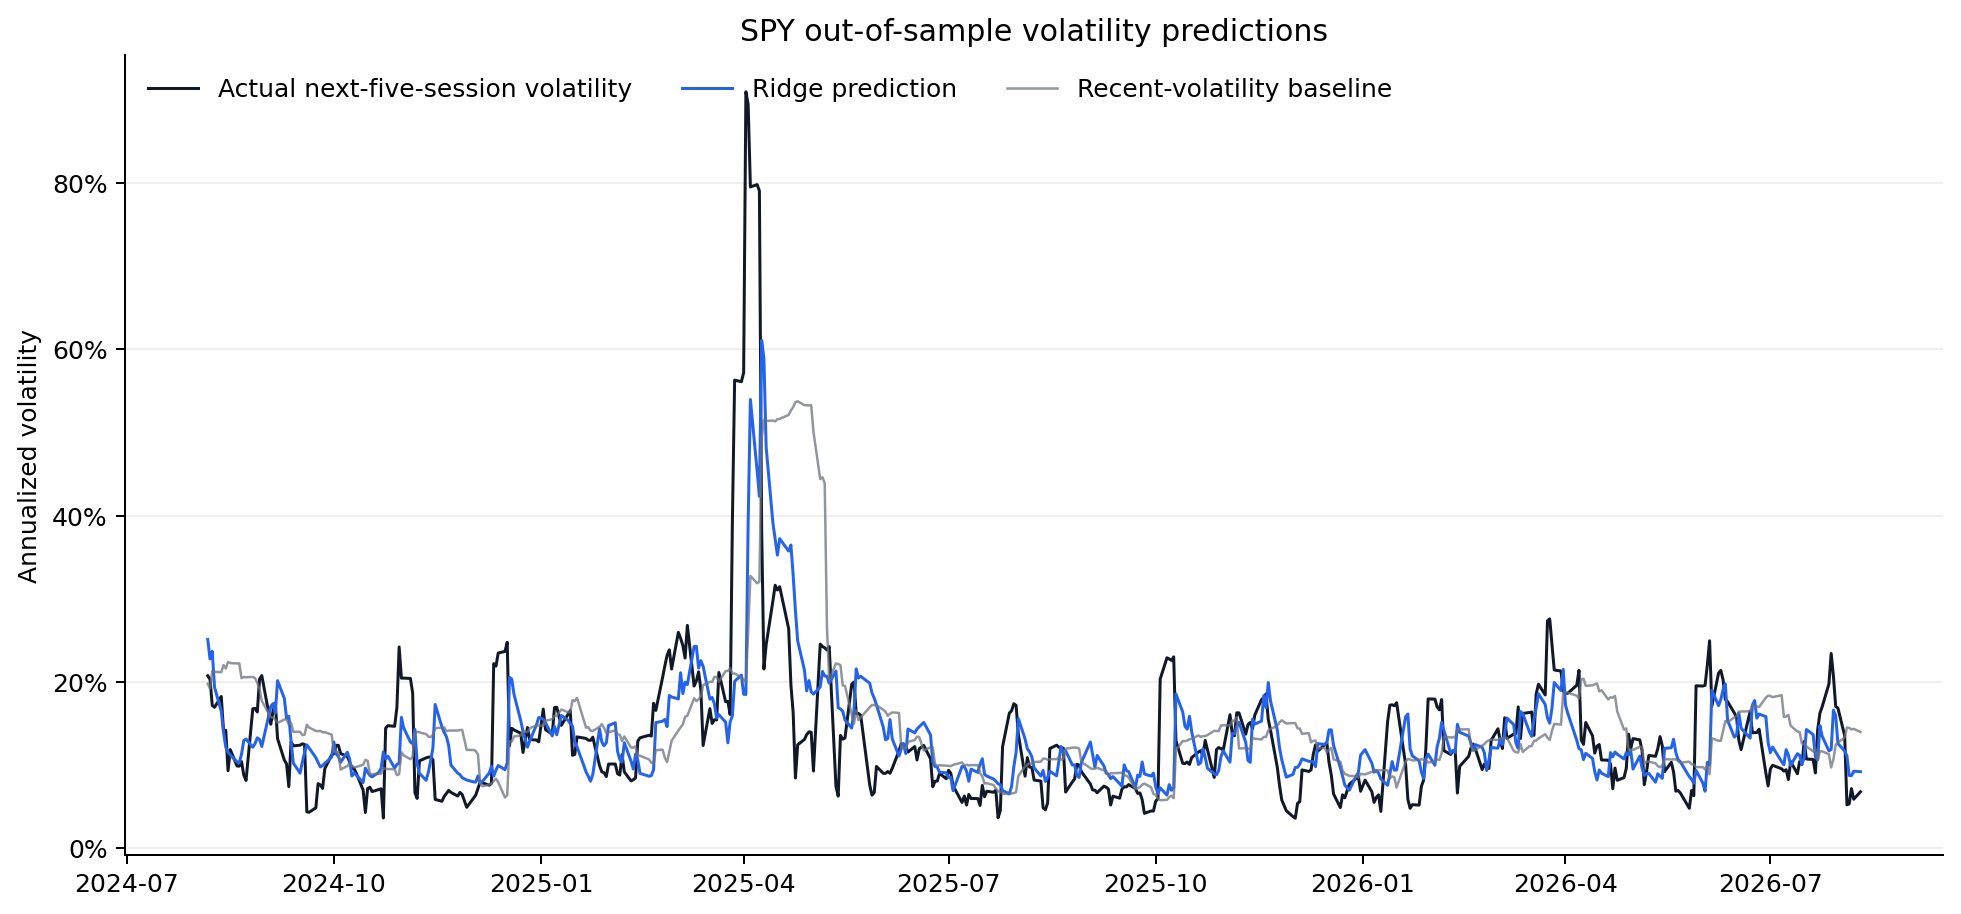

In [9]:
display(Image(filename=str(ROOT / 'reports/images/regression_predictions.png'), width=900))

The split is chronological and purged. Because each target uses the next five sessions, a five-row embargo prevents any training target from containing a holdout date. The recent-volatility baseline represents the simple time-series answer; Ridge must improve on it to justify added complexity.

In [10]:
pd.Series({
    'Training rows': metrics['models']['train_rows'],
    'Training end': metrics['models']['train_end'],
    'Embargo sessions': metrics['models']['embargo_rows'],
    'Holdout start': metrics['models']['test_start'],
    'Holdout forecast windows': metrics['models']['test_rows'],
}, name='value').to_frame()

,value
Training rows,3335
Training end,2023-04-03
Embargo sessions,5
Holdout start,2023-04-12
Holdout forecast windows,835


In [11]:
classification = metrics['models']['classification']
classification_table = pd.DataFrame({
    'Logistic model': classification['logistic'],
    'Prior baseline': classification['prior_baseline'],
}).T
display(classification_table.round(3))
print(classification['score_interpretation'])

,accuracy,balanced_accuracy,precision,recall,f1,mean_risk_score,brier_score,log_loss,roc_auc
Logistic model,0.811,0.727,0.372,0.613,0.463,0.339,0.143,0.463,0.777
Prior baseline,0.867,0.500,0.000,0.000,0.000,0.250,0.129,0.434,0.500


Class-weighted logistic output used for ranking and the decision rule; it is not a calibrated event probability.


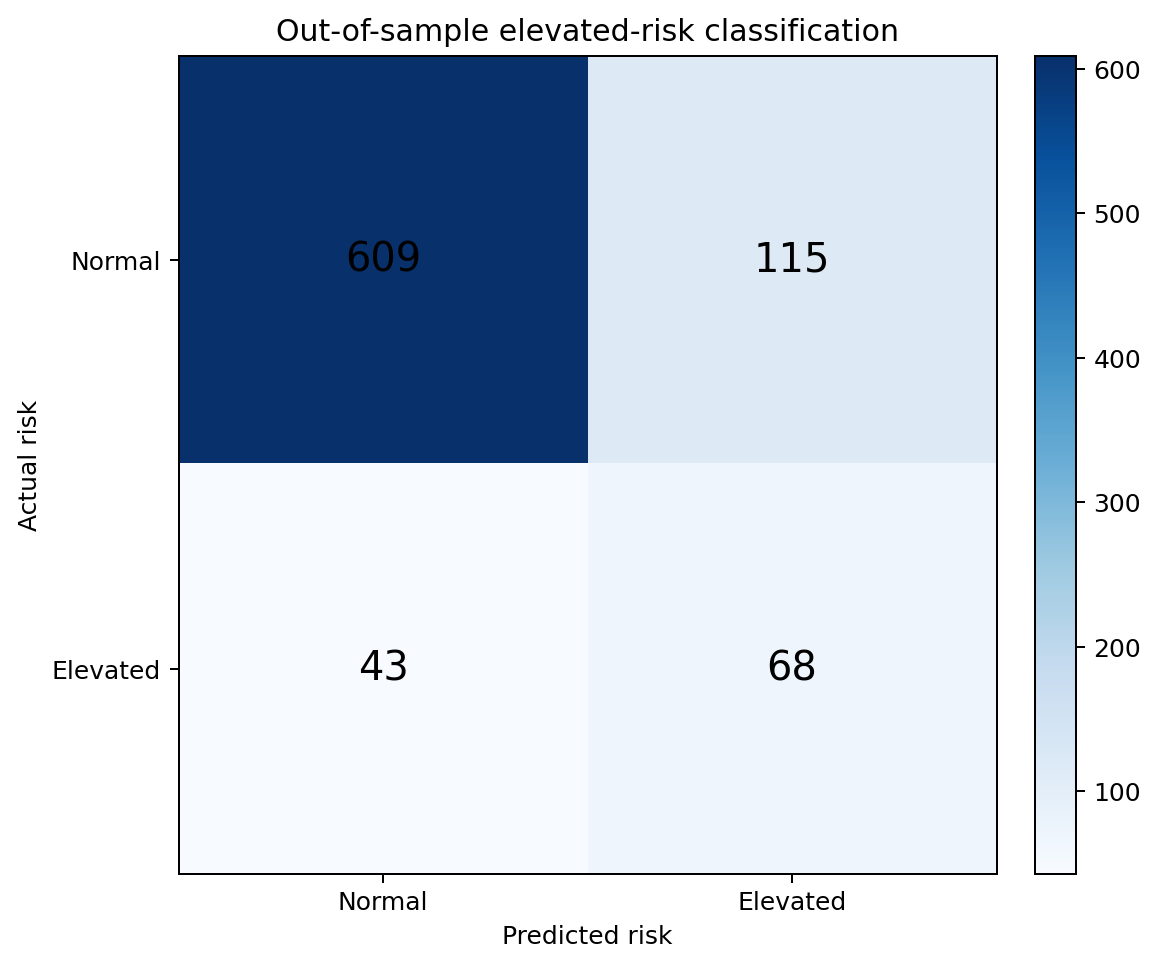

In [12]:
display(Image(filename=str(ROOT / 'reports/images/classification_confusion_matrix.png'), width=600))

## 5. Robustness across non-overlapping windows and regimes

Adjacent daily five-session targets overlap. Each offset below samples every fifth holdout row, producing five non-overlapping sequences rather than calling all 835 observations independent weeks.

In [13]:
non_overlap = pd.DataFrame(metrics['models']['diagnostics']['non_overlapping_windows'])
display(non_overlap.round(3))

,offset,rows,elevated_windows,ridge_mae,ridge_mae_improvement_vs_recent,balanced_accuracy,recall
0,0,167,21,0.041,0.166,0.683,0.524
1,1,167,22,0.042,0.189,0.758,0.682
2,2,167,23,0.039,0.225,0.753,0.652
3,3,167,24,0.040,0.222,0.708,0.583
4,4,167,21,0.039,0.235,0.731,0.619


In [14]:
yearly = pd.DataFrame(metrics['models']['diagnostics']['calendar_year'])
display(yearly.round(3))

,year,rows,elevated_rate,ridge_mae,recent_volatility_baseline_mae,balanced_accuracy,recall,roc_auc
0,2023,182,0.044,0.031,0.031,0.624,0.500,0.682
1,2024,252,0.107,0.036,0.043,0.618,0.333,0.796
2,2025,250,0.192,0.054,0.075,0.828,0.833,0.841
3,2026,151,0.185,0.035,0.047,0.715,0.536,0.729


Year-by-year recall varies materially, so the aggregate score does not imply stable behavior in every regime. The expanding-window test below repeatedly refits on the past, keeps a five-session embargo, and evaluates the next block.

In [15]:
walk_forward = metrics['models']['diagnostics']['walk_forward']
display(pd.DataFrame(walk_forward['folds']).round(3))
display(pd.Series(walk_forward['aggregate'], name='aggregate').to_frame())

,fold,train_rows,test_rows,train_end,test_start,test_end,ridge_mae,ridge_mae_improvement_vs_recent,balanced_accuracy,recall
0,1,830,835,2013-04-22,2013-04-30,2016-08-19,0.038,0.214,0.707,0.476
1,2,1665,835,2016-08-12,2016-08-22,2019-12-13,0.042,0.125,0.762,0.672
2,3,2500,835,2019-12-06,2019-12-16,2023-04-11,0.062,0.194,0.762,0.859
3,4,3335,835,2023-04-03,2023-04-12,2026-08-10,0.040,0.208,0.727,0.613


,aggregate
rows,3340.000000
ridge_mae,0.045697
ridge_mae_improvement_vs_recent,0.186443
balanced_accuracy,0.792623
recall,0.741313
roc_auc,0.863330


## 6. Residual, outlier, threshold, and feature-window sensitivity

In [16]:
display(pd.Series(metrics['models']['diagnostics']['residuals'], name='value').to_frame().round(4))
display(pd.DataFrame(metrics['models']['diagnostics']['outlier_feature_ablation']).T.round(4))

,value
mean_actual_minus_predicted,-0.0006
lag_1_autocorrelation,0.7477
highest_actual_vol_quartile_mean_actual_minus_predicted,0.0496
highest_actual_vol_quartile_mae,0.0722
top_actual_vol_decile_mean_actual_minus_predicted,0.0850
top_actual_vol_decile_mae,0.1210


,ridge_mae,balanced_accuracy,recall
with_flag,0.0402,0.7269,0.6126
without_flag,0.0404,0.7245,0.6036


Residuals remain serially correlated, and Ridge underpredicts the highest realized-volatility decile. The outlier flag has only a small incremental effect, so it should not be interpreted as the model's main driver.

In [17]:
sensitivity = pd.DataFrame(metrics['sensitivity']['risk_threshold'])
formatted_sensitivity = sensitivity.copy()
for column in formatted_sensitivity.columns:
    formatted_sensitivity[column] = formatted_sensitivity[column].map(lambda value: f'{value:.1%}')
display(formatted_sensitivity)
display(pd.DataFrame(metrics['sensitivity']['feature_windows']).round(4))

,risk_quantile,risk_threshold_annualized_vol,balanced_accuracy,precision,recall,f1
0,70.0%,16.3%,70.7%,44.6%,59.0%,50.8%
1,75.0%,17.8%,72.7%,37.2%,61.3%,46.3%
2,80.0%,19.7%,72.6%,32.6%,57.1%,41.5%


,short_window_days,long_window_days,ridge_mae,ridge_mae_improvement_vs_recent,balanced_accuracy,recall
0,5,20,0.0402,0.2075,0.7269,0.6126
1,10,30,0.0408,0.2275,0.7269,0.6306
2,10,60,0.0418,0.2549,0.6850,0.5495


In [18]:
display(pd.Series(metrics['feature_relationships'], name='correlation').to_frame().round(3))

,correlation
volume_z_20_vs_current_rolling_vol_20,-0.082
volume_z_20_vs_absolute_daily_return,0.358
volume_z_20_vs_next_five_day_vol,0.181


Threshold and feature-window choices change precision, recall, and baseline improvement. Standardized volume is more related to absolute same-day return than to current rolling volatility; these are descriptive correlations, not causal claims.

## 7. Current stakeholder signal

In [19]:
snapshot = metrics['latest_risk_snapshot']
pd.Series({
    'As-of date': snapshot['as_of_date'],
    'SPY adjusted close': f"${snapshot['adjusted_close']:,.2f}",
    '20-day annualized volatility': f"{snapshot['rolling_vol_20']:.1%}",
    'Predicted next-five-session volatility': f"{snapshot['predicted_next_five_day_vol']:.1%}",
    'Elevated-risk score': f"{snapshot['elevated_risk_score']:.1%}",
    'Decision cutoff': f"{snapshot['risk_score_cutoff']:.0%}",
    'All-history target threshold': f"{snapshot['risk_threshold_annualized_vol']:.1%}",
    'Classification': snapshot['risk_classification'].upper(),
    'Decision language': snapshot['decision_language'],
}, name='value').to_frame()

,value
As-of date,2026-08-17
SPY adjusted close,$772.67
20-day annualized volatility,13.5%
Predicted next-five-session volatility,11.3%
Elevated-risk score,25.2%
Decision cutoff,50%
All-history target threshold,17.1%
Classification,NORMAL
Decision language,The model does not flag elevated risk; maintai...


The current signal uses the separate production refit on all 4,175 labeled observations. Holdout metrics above remain tied to the purged evaluation fit.

## 8. Assumptions, risks, and conclusion

- The five-trading-day horizon approximates a weekly review cycle.
- Provider data and adjusted prices may be revised after retrieval.
- Historical relationships can break during regime changes.
- The 75th-percentile label is training-derived and sensitive to the selected quantile.
- The class-weighted logistic output is a risk score, not a calibrated event probability.
- Ridge materially underpredicts the most volatile realized windows.
- A normal signal does not mean the position is safe; it means the model does not detect elevated relative risk under its historical definition.
- The output is decision support, not an automated trade or guarantee.

The final recommendation is stored in `reports/final_summary.md`. The complete assumptions and risk register are maintained under `docs/`.

In [20]:
print(snapshot['decision_language'])

The model does not flag elevated risk; maintain exposure only within the existing mandate.


## Next steps

- Revisit the target threshold if the stakeholder supplies an explicit risk limit.
- Monitor provider schema and model performance after each refresh.
- Add a benchmark ETF only if it improves the decision rather than expanding scope.
- Stop model expansion when added complexity does not improve chronological out-of-sample evidence.